In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
sns.set(style="whitegrid")


In [2]:
# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display first 5 rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Shape of dataset
df.shape

# Column names
df.columns

# Check data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check missing values
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Check again
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

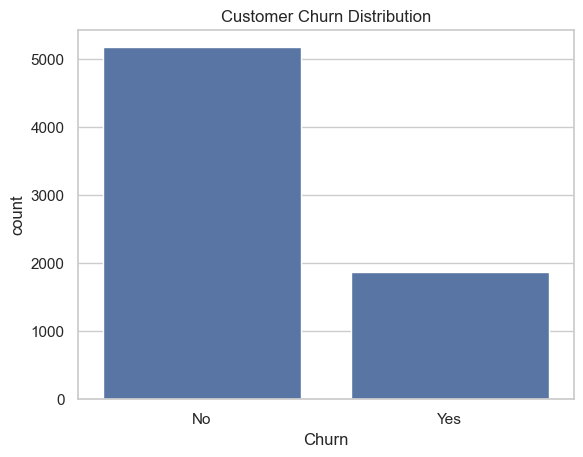

In [7]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()


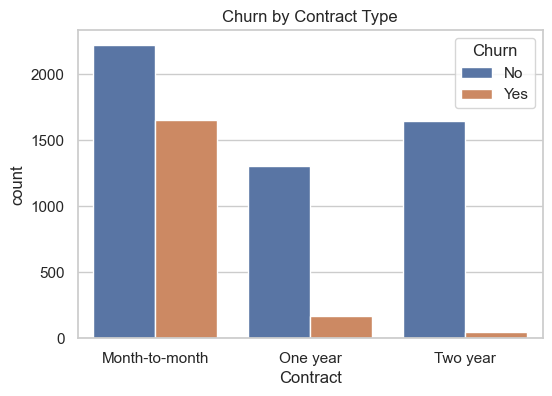

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")
plt.show()


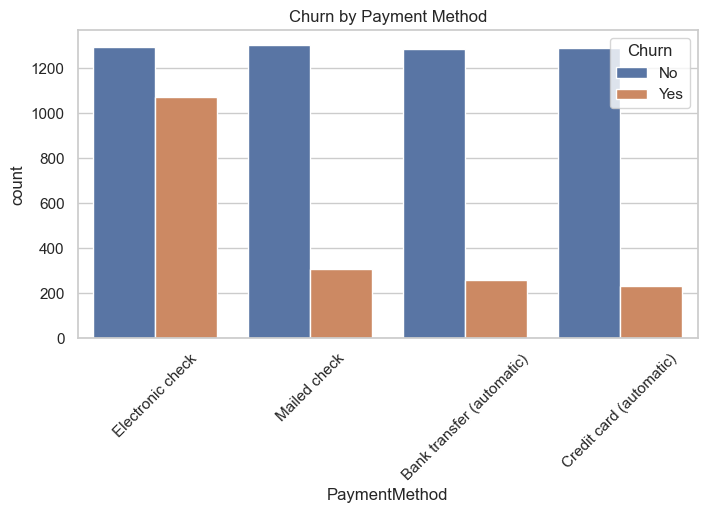

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()


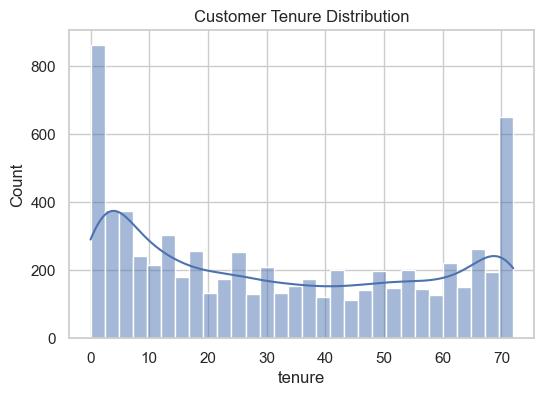

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.show()


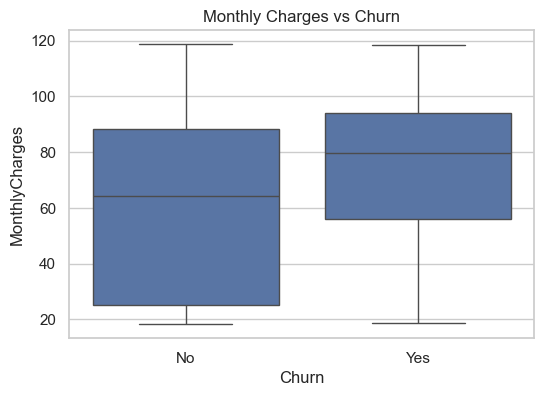

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.show()


In [12]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## Key Business Insights

1. Approximately **27% of customers have churned**, indicating a moderate churn rate.

2. Customers with **month-to-month contracts show the highest churn rate** compared to yearly contracts.

3. **Customers with higher monthly charges tend to churn more frequently**, suggesting pricing sensitivity.

4. Most churn occurs during the **early tenure period**, meaning new customers are at higher risk of leaving.

5. Certain **payment methods show higher churn rates**, which may indicate friction in the billing experience.


## Business Recommendations

1. Encourage customers to switch from **month-to-month plans to annual contracts** by offering discounts.

2. Improve **onboarding experience for new customers** to reduce early churn.

3. Provide **loyalty rewards or discounts for long-tenure customers**.

4. Review pricing strategy for customers with **higher monthly charges**.

5. Simplify and optimize **payment processes** to reduce churn caused by billing issues.


## Conclusion

This analysis explored customer churn patterns using the Telco Customer Churn dataset. 
The study identified contract type, monthly charges, and customer tenure as key drivers of churn. 

By focusing on improving customer onboarding, promoting long-term contracts, and optimizing pricing strategies, businesses can significantly improve customer retention and reduce churn rates.
